In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [16]:
df = pd.read_csv('/content/iris_flower_categorical.csv')

In [17]:
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,Short,Wide,Short,Narrow,setosa
1,Short,Medium,Short,Narrow,setosa
2,Short,Medium,Short,Narrow,setosa
3,Short,Medium,Short,Narrow,setosa
4,Short,Wide,Short,Narrow,setosa


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sepal_length  150 non-null    object
 1   sepal_width   150 non-null    object
 2   petal_length  150 non-null    object
 3   petal_width   150 non-null    object
 4   species       150 non-null    object
dtypes: object(5)
memory usage: 6.0+ KB


In [7]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150,150,150,150,150
unique,3,3,3,3,3
top,Medium,Medium,Long,Medium,setosa
freq,67,105,51,52,50


In [8]:
df.dtypes

,0
sepal_length,object
sepal_width,object
petal_length,object
petal_width,object
species,object


In [18]:
X = df.drop('species', axis = 1)
Y = df['species']

In [19]:
X_encoded = X.copy()

for col in X_encoded.columns:
  if X_encoded[col].dtypes == 'object':
     X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])


In [21]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X_encoded)

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scale, Y, test_size=0.2, random_state= 42)

In [24]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=3)

In [25]:
y_predict = model.predict(X_test)

In [28]:
print("Accuracy:", accuracy_score(Y_test, y_predict))
print("\nClassification Report:\n", classification_report(Y_test, y_predict))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



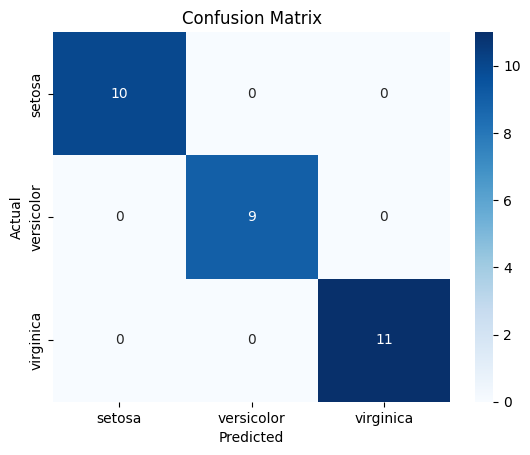

In [30]:
cm = confusion_matrix(Y_test, y_predict)
sns.heatmap(cm, annot = True, cmap = "Blues", fmt= "d", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

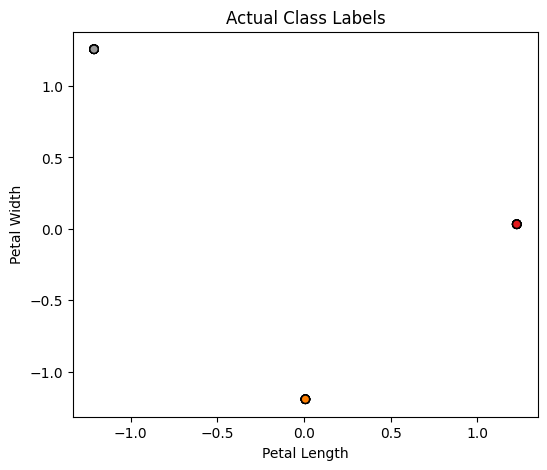

In [34]:
le = LabelEncoder()
Y_test_encoded = le.fit_transform(Y_test)

plt.figure(figsize=(6, 5))
plt.scatter(X_test[:, 2], X_test[:, 3], c=Y_test_encoded, cmap="Set1", edgecolor='k')
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Actual Class Labels")
plt.show()